In [1]:
# Также тебе понадобится библиотека vk_api
!pip install vk_api

In [2]:
import json # В json файл сохрани свой ключ
import vk_api

from tqdm import tqdm

Далее представлен класс для парсинга постов из сообществ ВКонтакте. Он получает всю информацию из поста и складывает в словарь. То есть все будет храниться в оперативной памяти. Если у тебя будет много данных или ты не хочешь парсить те же самые данные каждый раз, как запускаешь ноутбук, то рекоммендуется доработать класс для сохранения полученных данных на диск.

In [5]:
class VkParser:

    def __init__(self, list_of_groups, list_of_offsets, n_posts=100, config='config.json'):
        '''
        list_of_groups — список id сообществ, которые ты собираешься парсить
        list_of_offsets — список размера list_of_groups, где каждый элемент обозначает, сколько первых постов мы хотим распарсить. Если значение 0, то парсятся все посты.
        n_posts — информацию по какому количеству постов получать за раз
        config — путь до полученной тобой ключа API
        '''
        self.list_of_groups = list_of_groups
        self.list_of_offsets = list_of_offsets
        self.n_posts = n_posts
        self.data = {} # Контейнер, чтобы хранить информацию по группам

        with open(config, "r", encoding="utf-8") as config_file:
            self.api = vk_api.VkApi(token=json.load(config_file)["access_token"])
    
    # Функция для определения максимального количества постов в сообществе
    def _get_max_offset(self, group):
        return self.api.method(method="wall.get", values={
            "domain": group,
            "offset": 0,
            "count": 1
            })['count']
    
    # Функция для парсинга постов из сообщества
    def parse_group(self, group, offset):
        group_data = [] # Хранилище для данных
        current_offset = 0 # Парсим с начала
        max_offset = self._get_max_offset(group)
        if offset == 0:
            offset_range = max_offset // self.n_posts + 1
        else:
            offset = min(offset, max_offset) # Ограничиваем offset максимальным значением
            offset_range = offset // self.n_posts
        for current_offset in tqdm(range(offset_range)):
            group_data.extend(self.api.method(method="wall.get", values={
                "domain": group,
                "offset": current_offset * self.n_posts,
                "count": self.n_posts
            })['items'])
            
            # current_offset += self.n_posts # Обновляем текущий счетчик

        return group_data
    
    # Функция для парсинга всех постов из всех сообществ в списке
    def parse_all_groups(self):
        for group, offset in zip(self.list_of_groups, self.list_of_offsets):
            print(f'Парсим {group}')
            self.data[group] = self.parse_group(group, offset)

In [7]:
# Пример использования
# Id группы, это то, что идет после ссылки на соц. сеть. То есть для https://vk.com/central_university, будет central_university
groups = ['mudakoff', 'pikabu', 'rhymes']
offsets = [1000, 1000, 1000]
parser = VkParser(groups, offsets, 200)
parser.parse_all_groups()

Парсим mudakoff


100%|██████████| 5/5 [00:07<00:00,  1.51s/it]


Парсим pikabu


100%|██████████| 5/5 [00:05<00:00,  1.19s/it]


Парсим rhymes


100%|██████████| 5/5 [00:08<00:00,  1.63s/it]


In [8]:
# Получили все со стены
len(parser.data['pikabu'])

500

In [14]:
# Рассмотрим 1-ый пост
parser.data['mudakoff'][50]

{'inner_type': 'wall_wallpost',
 'comments': {'count': 263},
 'marked_as_ads': 0,
 'hash': 's93-ZmA5r7BodNIoFg',
 'type': 'post',
 'push_subscription': {'is_subscribed': False},
 'attachments': [{'type': 'photo',
   'photo': {'album_id': -7,
    'date': 1752390775,
    'id': 460771297,
    'owner_id': -57846937,
    'access_key': 'e4875479fff86a2b74',
    'post_id': 46893122,
    'sizes': [{'height': 90,
      'type': 's',
      'width': 72,
      'url': 'https://sun9-29.userapi.com/s/v1/ig2/G0nl7e01jz8Ci6bCfreLmZ1MTYQjSRRvowEJ8f3AYW1jlF15gBcfW9vQKmq0EDTEm3IrwSAnTgTtvt52orChMR66.jpg?quality=95&as=32x40,48x60,72x90,108x135,160x199,240x299,360x449,480x598,540x673,640x798,720x897,1080x1346,1280x1595,1291x1609&from=bu&cs=72x0'},
     {'height': 199,
      'type': 'm',
      'width': 160,
      'url': 'https://sun9-29.userapi.com/s/v1/ig2/G0nl7e01jz8Ci6bCfreLmZ1MTYQjSRRvowEJ8f3AYW1jlF15gBcfW9vQKmq0EDTEm3IrwSAnTgTtvt52orChMR66.jpg?quality=95&as=32x40,48x60,72x90,108x135,160x199,240x299,360x4

In [18]:
# Ты можешь достать из него текст, просмотры, репосты, лайки, ссылки на фотографии и прочую информацию
parser.data['mudakoff'][0]['text'], parser.data['mudakoff'][0]['reposts'], parser.data['mudakoff'][0]['views'], parser.data['mudakoff'][0]['likes']

('Когда ключевые ставки на жилье взлетели до небес, на что только не пойдёшь, чтобы продать квартиру.\n\nИзвините, но я лучше в коробке поживу...',
 {'count': 26},
 {'count': 7953},
 {'can_like': 0, 'count': 13, 'user_likes': 0})

In [19]:
# Если хочешь скачать все фотографии, то их придется парсить отдельно, тебе в этом поможет функция ниже
import requests
from PIL import Image

import pandas as pd # Для хранения таблицы с колонками номер поста, номер фото, ссылка на фото

def parse_photos(links, save_root):
    '''
    links — словарь формата id фотографии: ссылка на нее
    save_root — путь до папки, куда сохранять
    '''
    save_root = '/data/' + save_root
    if not os.path.exists(save_root):
        os.makedirs(save_root)

    for i in tqdm(range(len(links))):
        im = Image.open(requests.get(links[i], stream=True).raw)
        im.save(f'{save_root}/{i}.jpg')
    print('Готово')
    

In [51]:
# Получим все ссылки на фото
def get_posts_info(group, quality=1, n_photos=300):
    '''
    parser — объект класса VkParser, который уже распарсил данные
    Возвращает два списка: ids фотографий и ссылки на них
    '''
    photos_links = []
    likes, reposts, views = [], [], []
    for post in parser.data[group]:

        photos = [el for el in post['attachments'] if el['type'] == 'photo']
        if photos:
            ph = photos[0]
            photos_links.append(ph['photo']['sizes'][quality]['url'])
            likes.append(post['likes']['count'])
            reposts.append(post['reposts']['count'])
            views.append(post['views']['count'])

    return photos_links[:n_photos], likes[:n_photos], reposts[:n_photos], views[:n_photos]


In [52]:
links_df = pd.DataFrame(columns=['photo_link', 'group_id'])
for i in range(len(groups)):
    links, likes, reposts, views = get_posts_info(groups[i], n_photos=500)
    links_df = pd.concat([links_df, pd.DataFrame({
        'photo_link': links, 
        'group_id': i, 
        'likes': likes, 
        'reposts': reposts, 
        'views': views})], 
        ignore_index=True)

links_df

,photo_link,group_id,likes,reposts,views
0,https://sun9-46.userapi.com/s/v1/ig2/-GmAOLHFf...,0,13.0,26.0,7953.0
1,https://sun9-23.userapi.com/s/v1/ig2/Nkug4HtnS...,0,63.0,180.0,46323.0
2,https://sun9-34.userapi.com/s/v1/ig2/nMN0n-h_o...,0,1145.0,1560.0,277090.0
3,https://sun9-48.userapi.com/s/v1/ig2/wwSQwju3_...,0,271.0,349.0,60881.0
4,https://sun9-26.userapi.com/s/v1/ig2/78CHgxz9m...,0,310.0,1467.0,227629.0
...,...,...,...,...,...
945,https://sun9-80.userapi.com/s/v1/ig2/4yy5xdPZm...,2,866.0,893.0,372759.0
946,https://sun9-40.userapi.com/s/v1/ig2/XRARQRxrC...,2,602.0,1038.0,329054.0
947,https://sun9-34.userapi.com/s/v1/ig2/CUyIPsuF6...,2,547.0,445.0,223666.0
948,https://sun9-46.userapi.com/s/v1/if2/-9VrNr77t...,2,286.0,1062.0,204222.0


### Сохраняем данные локально и в виде тензора

In [ ]:
import os
import asyncio
import aiohttp
from PIL import Image
from io import BytesIO
import hashlib
import pandas as pd
from tqdm.asyncio import tqdm_asyncio
import torch
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np

output_dir = "/Users/mhlgvr/Documents/Yandex.Disk.localized/CU2/AI/Bootcamps 2025/memobot/data/images-with-likes"
meta_csv = "/Users/mhlgvr/Documents/Yandex.Disk.localized/CU2/AI/Bootcamps 2025/memobot/data/metadata.csv"
os.makedirs(output_dir, exist_ok=True)

image_urls = links_df['photo_link']
targets = links_df[['likes', 'reposts', 'views']]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),          # [0, 1], shape: [C, H, W]
])

# Ограничение параллелизма
semaphore = asyncio.Semaphore(10)  # максимум 10 одновременных загрузок

# Таймауты
timeout = aiohttp.ClientTimeout(total=30)

# Список для ошибок
failed = []

async def download_image(session, i, url, retries=3):
    async with semaphore:
        for attempt in range(1, retries + 1):
            try:
                async with session.get(url) as response:
                    if response.status != 200:
                        raise aiohttp.ClientResponseError(
                            request_info=response.request_info,
                            history=response.history,
                            status=response.status,
                            message=f"HTTP status {response.status}",
                            headers=response.headers,
                        )

                    content = await response.read()
                    image = Image.open(BytesIO(content)).convert("RGB")
                    tensor = transform(image)

                    # Хэш файла
                    hash_name = hashlib.md5(content).hexdigest()
                    filename = f"{hash_name}.jpg"
                    filepath = os.path.join(output_dir, filename)

                    if not os.path.exists(filepath):
                        image.save(filepath, format="JPEG")

                    return {
                        "tensor": tensor,
                        "label": labels[i] if i < len(labels) else None,
                        "filename": filename,
                        "url": url
                    }

            except Exception as e:
                if attempt == retries:
                    print(f"❌ [{url}] — провал после {retries} попыток. Ошибка: {e}")
                    failed.append(url)
                else:
                    await asyncio.sleep(1)  # пауза перед повтором

    return None


async def download_all(urls):
    results = []
    async with aiohttp.ClientSession(timeout=timeout) as session:
        tasks = [
            asyncio.create_task(download_image_tensor(session, i, url))
            for i, url in enumerate(urls)
        ]
        results_raw = await tqdm_asyncio.gather(*tasks, desc="Загрузка изображений")
        results = [r for r in results_raw if r is not None]
    return results

In [14]:
import nest_asyncio
nest_asyncio.apply()

loop = asyncio.get_event_loop()
image_data = loop.run_until_complete(download_all(image_urls))

meta = []
tensors = []

for item in image_data:
    meta.append({
        "filename": item["filename"],
        "url": item["url"],
        "label": item["label"]
    })
    tensors.append(item["tensor"])

df = pd.DataFrame(meta)
df.to_csv(meta_csv, index=False)
print(f"\nСкачано: {len(tensors)} изображений. Метаданные сохранены в {meta_csv}")

# Пример: стек всех изображений в батч [N, C, H, W]
batch_tensor = torch.stack(tensors)
labels_tensor = torch.tensor(df['label'].values)
print(f"Форма батча: {batch_tensor.shape}")  # [N, 3, 224, 224]


Загрузка изображений: 100%|██████████| 3399/3399 [00:43<00:00, 78.45it/s] 



Скачано: 3399 изображений. Метаданные сохранены в dataset/metadata.csv
Форма батча: torch.Size([3399, 3, 224, 224])


## Выделим тестовые данные для проверки моделей

In [ ]:
import os

os.chdir('..')
print(os.getcwd())

In [ ]:
for filename in df['filename']:
    path = 'dataset/images/' + filename
    if not os.path.exists(path):
        df = df[df['filename'] != filename]


In [62]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

print(train_df['label'].value_counts(normalize=True))
print(test_df['label'].value_counts(normalize=True))
print(len(train_df), len(test_df))

label
2    0.147113
5    0.147113
3    0.147113
0    0.147113
6    0.147113
1    0.147113
4    0.117323
Name: proportion, dtype: float64
label
3    0.147059
5    0.147059
1    0.147059
6    0.147059
0    0.147059
2    0.147059
4    0.117647
Name: proportion, dtype: float64
2719 680


In [ ]:
import shutil


filenames = test_df['filename'].tolist()
src = 'notebooks/dataset/images'
target = 'data/test'
count = 0

for filename in filenames:
    src_from = os.path.join(src, filename)
    shutil.move(src_from, target)

print(count)

In [50]:
train_df.to_csv('data/train.csv', index=False)
test_df.to_csv('data/test.csv', index=False)


### Собираем датасет

In [66]:
from torch.utils.data import Dataset, DataLoader


class VkDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['label'])

        if self.transform:
            image = self.transform(image)

        return image, label


In [67]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])
images_folder = '/Users/mhlgvr/Documents/Yandex.Disk.localized/CU2/AI/Bootcamps 2025/memobot/data/train'

data = VkDataset(train_df, images_folder, transform=transform)
dataloader = DataLoader(data, batch_size=32, shuffle=True)

for images, labels in dataloader:
    print(f"🖼️ Batch size: {images.size()}, Labels: {labels}")
    break


🖼️ Batch size: torch.Size([32, 3, 224, 224]), Labels: tensor([6, 4, 4, 5, 5, 3, 3, 6, 2, 2, 2, 2, 6, 5, 0, 1, 3, 2, 4, 1, 0, 2, 4, 4,
        5, 5, 3, 0, 2, 1, 2, 1])


### Чекаем что все лэйблы соотвествуют

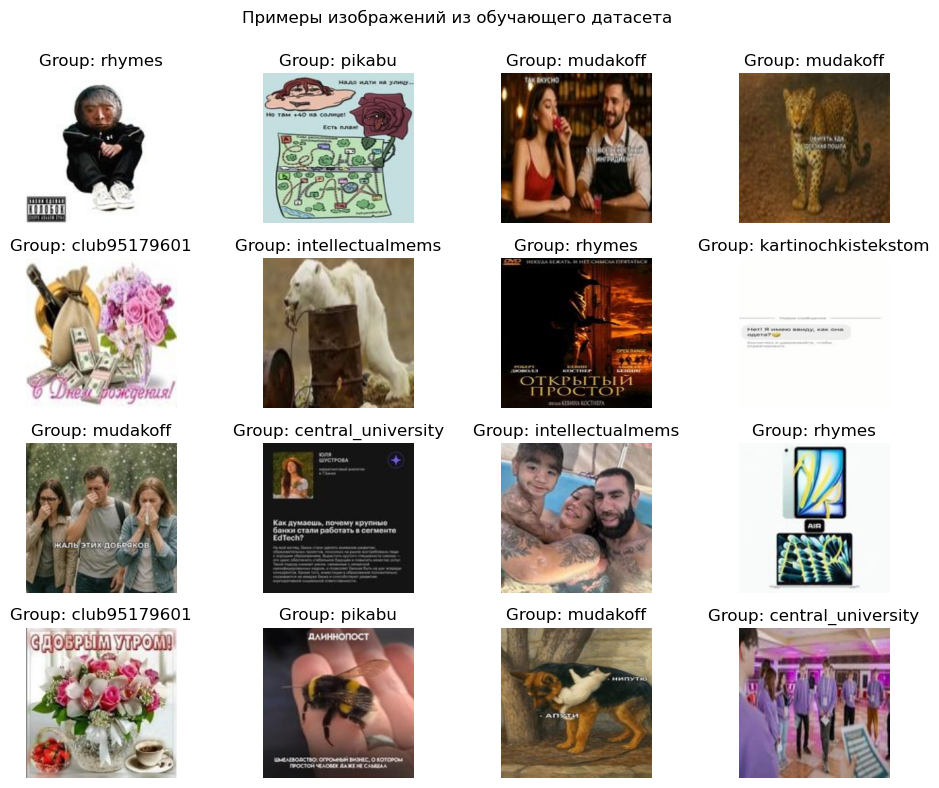

In [74]:
import matplotlib.pyplot as plt

groups = ['central_university', 'intellectualmems', 'mudakoff', 'club95179601', 'pikabu', 'rhymes', 'kartinochkistekstom']

plt.subplots(4, 4, figsize=(10, 8))
plt.suptitle("Примеры изображений из обучающего датасета")
j = 1
for i in np.random.randint(0, len(data), 16):
    plt.subplot(4, 4, j)
    j += 1
    img = data[i][0]
    label = data[i][1]
    plt.imshow(img.permute(1, 2, 0).numpy())  # Преобразуем тензор в формат [H, W, C]
    plt.title(f"Group: {groups[label]}")
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()